# Семинар 1. ReAct-агент с нуля и цена верного ответа

Собираем голого ReAct-агента на чистом Python: цикл, три инструмента, счётчик денег. К концу семинара агент решает задачи из GSM8K и HotpotQA, пишет трейс каждого прогона и показывает цену каждого верного ответа. В последнем спринте собираем каскад из дешёвой и сильной модели и смотрим, где тезис курса подтверждается уже сегодня.

Тезис курса: **хороший агент на дешёвой модели обходится дешевле сильной модели в одиночку при том же качестве.** Единица измерения на все шесть недель одна: цена верного ответа, то есть потраченные доллары, делённые на число верных ответов.

Семь спринтов, в каждом чекпоинт. Дырки это функции, у которых вместо тела стоит `...`, ни одна не длиннее десяти строк. Подробные пояснения, критерии домашки и частые проблемы в `README.md`.

## Ключ

**Локально.** Скопируйте `.env.example` в `.env` рядом с ноутбуком и впишите ключ в строку `OPENROUTER_API_KEY=`. Файл `.env` в git не коммитят.

**В Kaggle.** Ключ кладут в Secrets, а не в код:

1. Откройте ноутбук в Kaggle, в верхнем меню редактора выберите **Add-ons**, затем **Secrets**.
2. Нажмите **Add a new secret**. В поле Label впишите ровно `OPENROUTER_API_KEY`, в поле Value сам ключ, нажмите Save.
3. Убедитесь, что галочка напротив секрета включена: так он становится доступен этому ноутбуку.
4. В правой панели **Settings** включите **Internet**. Без подтверждённого телефона переключатель не работает: подтверждение в настройках профиля Kaggle.
5. Загрузите папку `data` как датасет: **Add Input**, **Upload**, имя `seminar01-data`. Ячейка ниже найдёт файлы сама.

Первая ячейка после установки пакетов прочитает секрет через `UserSecretsClient` и остановится с понятной ошибкой, если ключа нет.

In [1]:
%pip install -q requests pydantic python-dotenv pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, re, sys, json, time, ast, operator, subprocess
from pathlib import Path
from dataclasses import dataclass, field
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field, ValidationError

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}",
           "HTTP-Referer": "https://postypashki.ru", "X-Title": "agents-course-seminar01"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = next((p for p in [Path("qa_data"), Path("/kaggle/input/datasets/artmakar04/"), Path("/kaggle/input/seminar01-data/data")]
             if (p / "compare_10.jsonl").exists()), Path("qa-data"))
TRACES, IMG = Path("traces"), Path("img")
TRACES.mkdir(exist_ok=True)
IMG.mkdir(exist_ok=True)

## Спринт 1. Один вызов: цена и время

`Ledger` записывает каждый вызов: тег, модель, токены, стоимость и секунды. Стоимость не считается по прайсу: OpenRouter возвращает её в поле `usage.cost`, и это настоящая цифра со счёта. `chat()` отправляет сообщения, замеряет время и кладёт `usage` в леджер.

Дырка одна: HTTP-запрос с повтором. Код 429 на семинаре придёт обязательно, когда тридцать человек одновременно нажмут Shift+Enter, и агент, который падает от одного 429, не агент.

Чекпоинт: график «цена против времени ответа» по трём моделям на одном вопросе. Сильная модель не только дороже, но и медленнее, и это вторая ось, о которой обычно забывают.

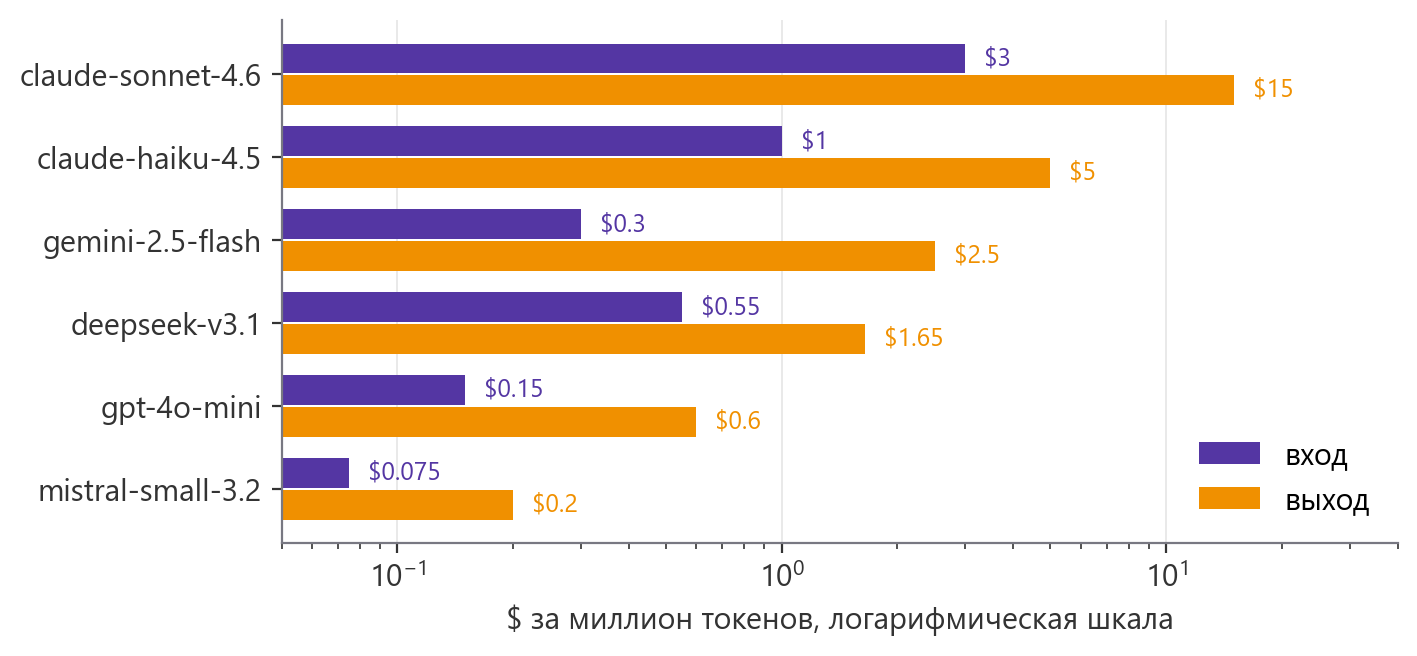

*Цены моделей на OpenRouter за миллион токенов, из первой лекции. Разрыв по входу в двадцать раз*

In [3]:
@dataclass
class Ledger:
    calls: list = field(default_factory=list)

    def add(self, tag, model, usage, seconds=0.0):
        p, c = usage.get("prompt_tokens", 0), usage.get("completion_tokens", 0)
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": p, "completion": c,
                           "cost": cost, "seconds": round(seconds, 2)})
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    def table(self):
        df = pd.DataFrame(self.calls)
        return df.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                completion=("completion", "sum"), cost=("cost", "sum"),
                                                seconds=("seconds", "sum")).round(5)

ledger = Ledger()

In [4]:
def post_with_retry(body, attempts=3):
    for attempt in range(attempts):
        r = requests.post(CHAT_URL, json=body, headers=HEADERS, timeout=120)
        if r.status_code == 200:
            return r.json()
        if r.status_code in (429, 500, 502, 503) and attempt < attempts - 1:
            time.sleep(1.5 * (attempt+1))
            continue
        raise RuntimeError(f"HTTP {r.status_code} : {r.text[:5000]}")

In [5]:
def chat(messages, model, tools=None, tag="chat", temperature=None):
    body = {"model": model, "messages": messages, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
        body["tool_choice"] = "auto"
    if temperature is not None:
        body["temperature"] = temperature
    started = time.perf_counter()
    data = post_with_retry(body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]

In [6]:
msg = chat([{"role": "user", "content": "Ответь одним словом: какого цвета небо?"}], MODELS["cheap"], tag="hello")
msg["content"], ledger.calls[-1]

('Синее.',
 {'tag': 'hello',
  'model': 'gpt-4o-mini',
  'prompt': 18,
  'completion': 4,
  'cost': 5.1e-06,
  'seconds': 2.24})

In [13]:
question = [{"role": "user", "content": "Объясни в трёх предложениях, что такое контекстное окно языковой модели. Включи максимально подробное объяснение"}]
answers = {name: chat(question, model, tag="window")["content"] for name, model in MODELS.items()}
ledger.table().loc["window"]

,calls,prompt,completion,cost,seconds
model,,,,,
claude-haiku-4.5,2,83,414,0.00215,5.19
claude-sonnet-4.6,2,83,492,0.00763,11.89
gpt-4o-mini,2,62,207,0.00013,4.11


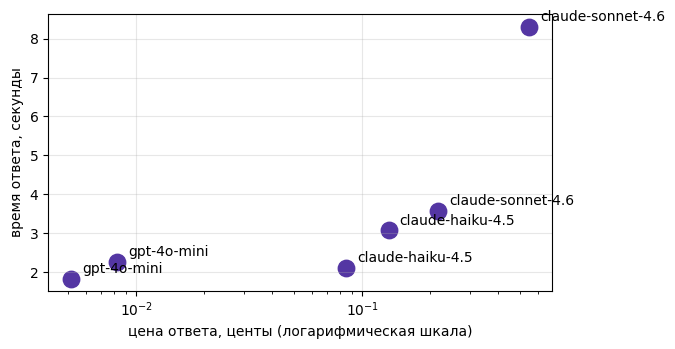

In [14]:
def cost_time_chart(tag):
    df = pd.DataFrame([c for c in ledger.calls if c["tag"] == tag])
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    ax.scatter(df["cost"] * 100, df["seconds"], s=140, color=COLORS["violet"])
    for _, r in df.iterrows():
        ax.annotate(r["model"], (r["cost"] * 100, r["seconds"]), xytext=(8, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("цена ответа, центы (логарифмическая шкала)")
    ax.set_ylabel("время ответа, секунды")
    ax.grid(alpha=0.3)
    return fig

cost_time_chart("window");

In [15]:
for name, text in answers.items():
    print(f"{name:7s}| {text[:230]}")

cheap  | Контекстное окно языковой модели — это ограниченное количество токенов (слов или символов), которые модель использует для генерации текста и понимания смысла при обработке входных данных. Размер контекстного окна определяет, сколь
mid    | # Контекстное окно языковой модели

Контекстное окно — это максимальное количество токенов (примерно слов или их частей), которые модель может одновременно обрабатывать и учитывать при генерации ответа, включая как входные данные 
strong | ## Контекстное окно языковой модели

**Контекстное окно** — это максимальный объём текста (измеряемый в **токенах** — условных единицах, примерно соответствующих слогам или коротким словам), который языковая модель способна одновр


## Спринт 2. Ответ по схеме и температура

Модель просят вернуть JSON по схеме Pydantic-модели `Answer`. Схема уходит в системный промпт, ответ проверяется той же моделью. Если ответ не прошёл проверку, текст ошибки возвращается модели, и она пробует снова. Этот приём, ошибка обратно модели как текст, дальше держит весь цикл агента.

`json_from` вытаскивает первый объект из текста и разбирает его терпимо к переносам строк внутри значений: модели любят оборачивать JSON словами и писать рассуждение в несколько строк.

Две демонстрации после дырки. Схема `Numeric` требует число, а вопрос про столицу Франции: смотрим, сколько вызовов уйдёт и чем кончится. И одна и та же просьба придумать название кофейни пять раз при температуре 0 и пять раз при 1.2.

In [24]:
class Answer(BaseModel):
    reasoning: str = Field(description="ход решения в два-три предложения")
    final: str = Field(description="только итоговый ответ: число или короткая фраза")

SCHEMA_PROMPT = "Отвечай строго одним JSON-объектом по этой схеме, без текста вокруг, строки в одну линию, без лишних отступов, \t, \n:\n{schema}"

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    if not m:
        raise ValueError("в ответе нет JSON")
    return json.loads(m.group(0), strict=False)

In [26]:
Answer.model_json_schema()

{'properties': {'reasoning': {'description': 'ход решения в два-три предложения',
   'title': 'Reasoning',
   'type': 'string'},
  'final': {'description': 'только итоговый ответ: число или короткая фраза',
   'title': 'Final',
   'type': 'string'}},
 'required': ['reasoning', 'final'],
 'title': 'Answer',
 'type': 'object'}

In [28]:
schema=Answer
SCHEMA_PROMPT.format(schema=json.dumps(schema.model_json_schema(), ensure_ascii=False))

'Отвечай строго одним JSON-объектом по этой схеме, без текста вокруг, строки в одну линию, без лишних отступов, \t, \n:\n{"properties": {"reasoning": {"description": "ход решения в два-три предложения", "title": "Reasoning", "type": "string"}, "final": {"description": "только итоговый ответ: число или короткая фраза", "title": "Final", "type": "string"}}, "required": ["reasoning", "final"], "title": "Answer", "type": "object"}'

In [46]:
def ask_structured(question, model, schema=Answer, attempts=3):
    messages = [
        {"role": "system", "content": SCHEMA_PROMPT.format(schema=json.dumps(schema.model_json_schema(), ensure_ascii=False))},
        {"role": "user", "content": question}
    ]
    for _ in range(attempts):
        msg = chat(messages, model, tag="struct")
        try:
            return schema.model_validate(json_from(msg["content"]))
        except (ValidationError, ValueError) as e:
            messages += [msg, {"role": "user", "content": f"Ответ не прошел проверку на структуру: {e}. Верни ответ по строгой JSON схеме"}]
    raise ValueError("Модель не справилась")

In [43]:
def load_tasks(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

task = load_tasks("/kaggle/input/datasets/artmakar04/qa-data/compare_10.jsonl")[0]
ans = ask_structured(task["question"], MODELS["cheap"])
ans, task["answer"]

(Answer(reasoning="Jerome's first friend pressed the doorbell 20 times. The second friend pressed it 20 + (1/4 * 20) = 25 times. The fourth friend pressed it 60 times, so the third friend pressed it 60 + 10 = 70 times. Therefore, the total number of doorbell rings is 20 + 25 + 60 + 70 = 175.", final='175'),
 '175')

In [49]:
class Numeric(BaseModel):
    final: float = Field(description="ответ числом")

calls_before = len(ledger.calls)
try:
    result = ask_structured("Какой год основания франции", MODELS["cheap"], Numeric)
except ValueError as e:
    result = e
print("вызовов потрачено:", len(ledger.calls) - calls_before, "| результат:", result)

вызовов потрачено: 1 | результат: final=843.0


In [48]:
prompt = [{"role": "user", "content": "Придумай название для кофейни рядом с университетом. Только название, два слова."}]
pd.DataFrame({f"temperature {t}": [chat(prompt, MODELS["cheap"], tag="temperature", temperature=t)["content"] for _ in range(5)]
              for t in (0.0, 1.2)})

,temperature 0.0,temperature 1.2
0,Кофейный Уголок,"""Кофейный Лектор"""
1,Кофейный Уголок,Студенческая Кофеечь.
2,Кофейный Уголок,Кафе Умных
3,Кофейный Уголок,Кофейный Уголок
4,Кофейный Уголок,«Умный кофе»


## Спринт 3. Три модели на десяти задачах

Код готов, здесь работа не писать, а предсказывать. До запуска запишите: какая модель решит больше, во сколько раз дороже окажется сильная и какая быстрее. Потом сравните с таблицей и тремя столбиками.

Проверка ответа для GSM8K: последнее число в ответе сравнивается с эталоном. Для HotpotQA: нормализованный эталон должен содержаться в ответе. Это грубо, и это намеренно: на шестой неделе появится LLM-судья, и вы уже будете знать, зачем он нужен.

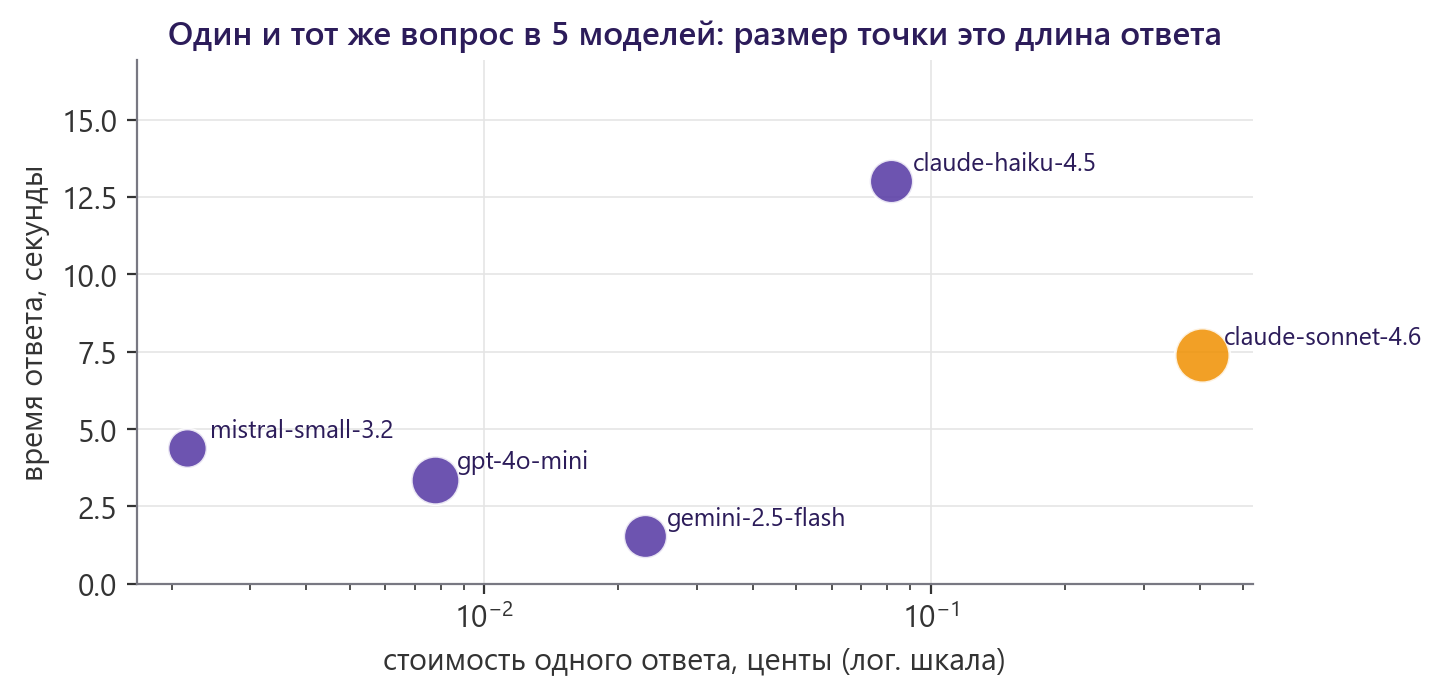

*Один вопрос в пяти моделях, из первой лекции: разброс по цене в тридцать раз, по времени ответа в десять*

In [50]:
def normalize(text):
    text = re.sub(r"[^\w\s]", " ", str(text).lower().replace(",", ""))
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    return " ".join(text.split())

def is_correct(task, answer):
    if task["source"] == "gsm8k":
        nums = re.findall(r"-?\d+(?:\.\d+)?", str(answer).replace(",", ""))
        return bool(nums) and abs(float(nums[-1]) - float(task["answer"])) < 1e-6
    return normalize(task["answer"]) in normalize(answer)

def summary(config, model, n, correct, cost, steps, seconds=0.0):
    return {"config": config, "model": model.split("/")[-1], "n": n, "accuracy": round(correct / n, 2),
            "cost_per_task": round(cost / n, 5), "cost_per_correct": round(cost / correct, 5) if correct else float("inf"),
            "avg_steps": round(steps, 2), "avg_seconds": round(seconds, 1)}

def compare_models(tasks, models):
    rows = []
    for name, model in models.items():
        before, correct, started = ledger.total, 0, time.perf_counter()
        for task in tasks:
            try:
                correct += is_correct(task, ask_structured(task["question"], model).final)
            except Exception:
                pass
        rows.append(summary("без инструментов, JSON", model, len(tasks), correct, ledger.total - before, 1,
                            (time.perf_counter() - started) / len(tasks)))
    return pd.DataFrame(rows)

def compare_chart(df):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    axes[0].bar(df["model"], df["accuracy"] * 100, color=COLORS["violet"])
    axes[0].set_ylabel("доля верных, %")
    axes[0].set_ylim(0, 105)
    axes[1].bar(df["model"], df["cost_per_correct"] * 100, color=COLORS["amber"])
    axes[1].set_ylabel("цена верного ответа, центы")
    axes[2].bar(df["model"], df["avg_seconds"], color=COLORS["teal"])
    axes[2].set_ylabel("секунд на задачу")
    for ax in axes:
        ax.tick_params(axis="x", labelrotation=12)
        ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    return fig

In [51]:
compare_df = compare_models(load_tasks("/kaggle/input/datasets/artmakar04/qa-data/compare_10.jsonl"), MODELS)
compare_df

,config,model,n,accuracy,cost_per_task,cost_per_correct,avg_steps,avg_seconds
0,"без инструментов, JSON",gpt-4o-mini,10,0.9,0.00009,0.00010,1,1.9
1,"без инструментов, JSON",claude-haiku-4.5,10,1.0,0.00128,0.00128,1,2.4
2,"без инструментов, JSON",claude-sonnet-4.6,10,1.0,0.00213,0.00213,1,2.3


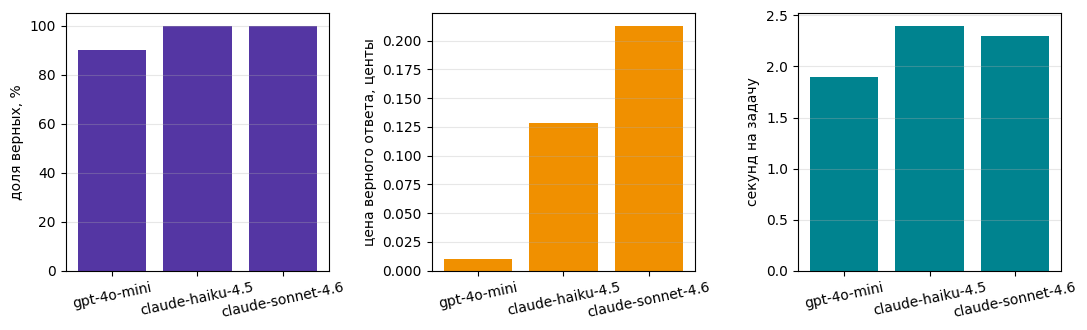

In [53]:
compare_chart(compare_df);

## Спринт 4. Цикл ReAct

Название из статьи Yao et al. (2022): модель чередует рассуждение и действие, а после каждого действия получает наблюдение. В нашем варианте рассуждение живёт внутри модели, а действия это вызовы инструментов через `tool_calls`.

Инструмент регистрируется функцией `register(fn, args_model, description)`: схема параметров берётся из Pydantic-модели, ею же потом проверяются аргументы, которые прислала модель. Калькулятор через `ast` дан готовым: он считает только арифметику, поэтому `__import__('os')` не пройдёт.

Две дырки: выполнение одного вызова инструмента и сам цикл. Обёртка `agent` замеряет цену и время, `finish` даёт агенту последний вызов без инструментов, когда сработало стоп-условие, `show_trace` печатает историю по шагам.

Четыре демонстрации после дырок: два шага на арифметику, параллельные вызовы в одном ответе, сломанный инструмент, который останавливает детектор повторов, и капризный инструмент, который останавливает только `max_steps`. По последнему прогону строим график роста контекста: живая версия картинки из второй лекции.

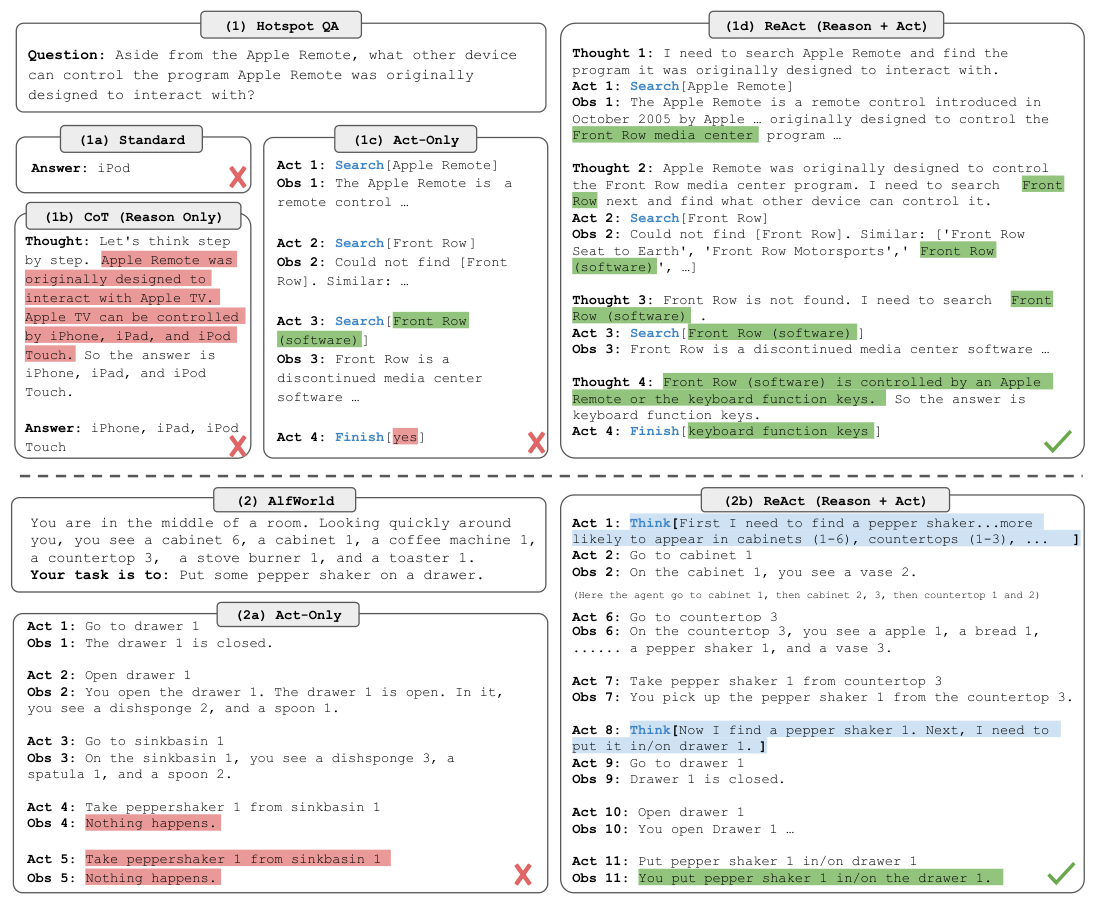

*Yao et al., 2022. ReAct: на одном вопросе из HotpotQA видно, почему рассуждение вместе с действиями выигрывает у каждого по отдельности*

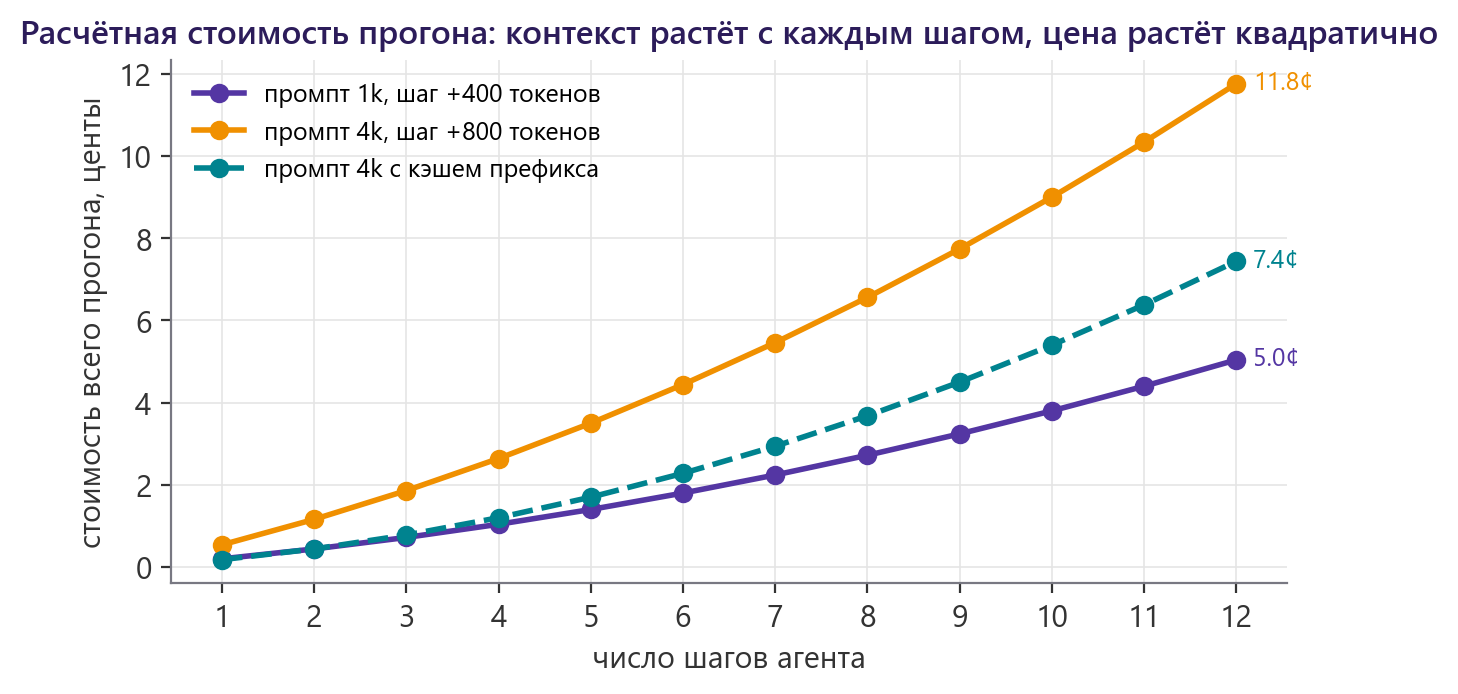

*Из второй лекции: контекст накапливается, и четыре шага агента стоят как восемь одиночных вызовов*

In [76]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
       ast.Pow: operator.pow, ast.USub: operator.neg, ast.Mod: operator.mod}

def evaluate(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.left), evaluate(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.operand))
    raise ValueError("допустимы только числа и арифметика")

class CalcArgs(BaseModel):
    expr: str = Field(description="арифметическое выражение, например 17*23+5")

def calculator(expr: str) -> str:
    try:
        val = evaluate(ast.parse(expr.replace(",", "."), mode="eval").body)
        return str(int(val)) if float(val).is_integer() else f"{val:.4f}".rstrip("0")
    except Exception as e:
        return f"ошибка вычисления: {e}"

register(calculator, CalcArgs, "Считает арифметическое выражение: числа, скобки, + - * / ** %")
json.dumps(TOOLS["calculator"]["schema"], ensure_ascii=False, indent=1)

'{\n "type": "function",\n "function": {\n  "name": "calculator",\n  "description": "Считает арифметическое выражение: числа, скобки, + - * / ** %",\n  "parameters": {\n   "properties": {\n    "expr": {\n     "description": "арифметическое выражение, например 17*23+5",\n     "title": "Expr",\n     "type": "string"\n    }\n   },\n   "required": [\n    "expr"\n   ],\n   "title": "CalcArgs",\n   "type": "object"\n  }\n }\n}'

In [77]:
SYSTEM = ("Ты решаешь задачи. Если нужно посчитать или найти факт, вызывай инструменты, а не угадывай. "
          "Когда ответ готов, напиши его последней строкой в формате FINAL: <ответ>. "
          "Для числовых задач в FINAL только число, для вопросов о фактах короткая фраза.")

@dataclass
class Run:
    question: str
    answer: str
    steps: int
    messages: list
    cost: float = 0.0
    seconds: float = 0.0

def looped(seen, calls):
    keys = [(c["function"]["name"], c["function"]["arguments"]) for c in calls]
    repeated = any(k in seen for k in keys)
    seen.update(keys)
    return repeated

def finish(model, messages, step):
    del messages[-1]
    messages.append({"role": "user", "content": "Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>."})
    msg = chat(messages, model, tag="agent")
    messages.append(msg)
    return msg.get("content") or "", step + 1

In [87]:
def run_tool(call):
    name = call["function"]["name"]

    try:
        spec = TOOLS[name]
        args = spec["args"].model_validate_json(call["function"]["arguments"])
        result = spec["fn"](**args.model_dump())
    except Exception as e:
        result = f"НЕ удалось вызвать инструмент {name}: {e}"
    return {"role": "tool", "tool_call_id" : call["id"], "content": str(result)[:2000]}


In [88]:
def agent_loop(messages, model, tool_names, max_steps):
    seen = set()
    for step in range(1, max_steps + 1):
        msg = chat(messages, model, tools=[TOOLS[n]["schema"] for n in tool_names] or None, tag='agent')
        messages.append(msg)
        calls = msg.get("tool_calls") or []

        if not calls:
            return msg.get("content") or "", step
        if looped(seen, calls) or step == max_steps:
            return finish(model, messages, step)

        messages += [run_tool(c) for c in calls]


In [89]:
def agent(question, model, tool_names, max_steps=8):
    messages = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": question}]
    before, started = ledger.total, time.perf_counter()
    answer, steps = agent_loop(messages, model, tool_names, max_steps)
    return Run(question, answer, steps, messages, ledger.total - before, time.perf_counter() - started)

def show_trace(run):
    for m in run.messages[1:]:
        calls = "; ".join(f"{c['function']['name']}{c['function']['arguments']}" for c in m.get("tool_calls") or [])
        text = " ".join((m.get("content") or "").split())[:180]
        print(f"{m['role']:9s}| {text} {calls}")
    print(f"шагов: {run.steps}, цена: {run.cost * 100:.3f} ¢, время: {run.seconds:.1f} c")

In [90]:
run = agent("Сколько будет 17 * 23 + 5? Посчитай инструментом.", MODELS["cheap"], ["calculator"])
show_trace(run)

user     | Сколько будет 17 * 23 + 5? Посчитай инструментом. 
assistant|  calculator{"expr":"17*23+5"}
tool     | 396 
assistant| FINAL: 396 
шагов: 2, цена: 0.007 ¢, время: 1.3 c


In [91]:
run = agent("Посчитай площадь круга радиусом 3 (пи возьми 3.14159) и объём куба со стороной 4. Верни оба числа.", MODELS["cheap"], ["calculator"])
show_trace(run)
[len(m.get("tool_calls") or []) for m in run.messages if m["role"] == "assistant"]

user     | Посчитай площадь круга радиусом 3 (пи возьми 3.14159) и объём куба со стороной 4. Верни оба числа. 
assistant|  calculator{"expr": "3.14159 * 3 ** 2"}; calculator{"expr": "4 ** 3"}
tool     | 28.2743 
tool     | 64 
assistant| FINAL: 28.2743, 64 
шагов: 2, цена: 0.011 ¢, время: 1.7 c


[2, 0]

In [92]:
class BrokenArgs(BaseModel):
    query: str = Field(description="любой запрос")

def broken_search(query: str) -> str:
    return "ошибка: сервис недоступен, попробуйте ещё раз"

register(broken_search, BrokenArgs, "Ищет ответ на любой вопрос в интернете")
run = agent("Кто написал роман «Мы»? Обязательно проверь через broken_search.", MODELS["cheap"], ["broken_search"], max_steps=8)
show_trace(run)

user     | Кто написал роман «Мы»? Обязательно проверь через broken_search. 
assistant|  broken_search{"query":"автор романа Мы"}
tool     | ошибка: сервис недоступен, попробуйте ещё раз 
user     | Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>. 
assistant| Роман «Мы» написал Евгений Замятин. FINAL: Евгений Замятин 
шагов: 3, цена: 0.011 ¢, время: 2.3 c


In [93]:
def flaky_search(query: str) -> str:
    return "ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова"

register(flaky_search, BrokenArgs, "Ищет ответ на любой вопрос в интернете")
run_flaky = agent("Кто написал роман «Мы»? Обязательно проверь через flaky_search, пока не получишь результат.", MODELS["cheap"], ["flaky_search"], max_steps=8)
show_trace(run_flaky)

user     | Кто написал роман «Мы»? Обязательно проверь через flaky_search, пока не получишь результат. 
assistant|  flaky_search{"query":"Кто написал роман «Мы»?"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant|  flaky_search{"query":"Автор романа Мы"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant|  flaky_search{"query":"Автор романа Мы Евгений Замятин"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant|  flaky_search{"query":"Роман Мы автор"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant|  flaky_search{"query":"Роман Мы Евгений Замятин"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant| Не удается получить результаты поиска. Однако, я знаю, что роман «Мы» написал Евгений Замятин. FINAL: Евгений Замятин 
шагов: 6, цена: 0.032 ¢, время: 5.9 c


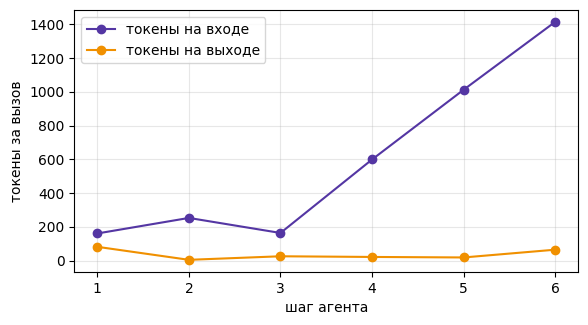

In [120]:
def context_chart(run):
    calls = [c for c in ledger.calls if c["tag"] == "agent"][-run.steps:]
    steps = range(1, len(calls) + 1)
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.plot(steps, [c["prompt"] for c in calls], marker="o", color=COLORS["violet"], label="токены на входе")
    ax.plot(steps, [c["completion"] for c in calls], marker="o", color=COLORS["amber"], label="токены на выходе")
    ax.set_xlabel("шаг агента")
    ax.set_ylabel("токены за вызов")
    ax.legend()
    ax.grid(alpha=0.3)
    return fig

context_chart(run_flaky);

## Спринт 5. Инструменты

Модель выбирает инструмент по имени и описанию, поэтому у каждого инструмента внятное описание и Pydantic-модель с описанием каждого поля. Это не оформление, это часть промпта.

Две дырки: поиск по Википедии и запуск кода в отдельном процессе. Запрос к Википедии с повтором при троттлинге дан готовым в `wiki()`. Ошибки инструмента возвращаются модели текстом: `ZeroDivisionError` в выводе это нормальный результат, модель его прочитает и поправит код. Отдельный процесс и таймаут это минимум изоляции, настоящий sandbox будет на пятой неделе.

Восемь `assert` проверяют каждый инструмент на трёх случаях: нормальный вход, пустой результат, ошибка. Дальше смотрим, что возвращает Википедия на неоднозначные запросы, считаем дни до конца года кодом и отвечаем на вопрос из HotpotQA поиском. В конце регистрируем `tool_a` и `tool_b`: те же инструменты, но с описанием «Инструмент» и полем без описания, для эксперимента в следующем спринте.

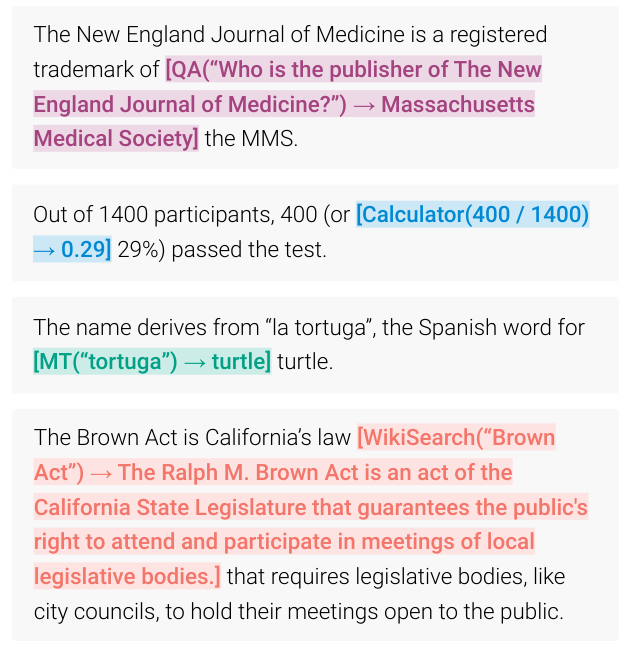

*Schick et al., 2023. Toolformer: модель сама вставляет вызовы калькулятора, поиска и календаря прямо в текст. Идея та же, что у нас, только вызовы у нас живут в отдельном поле ответа*

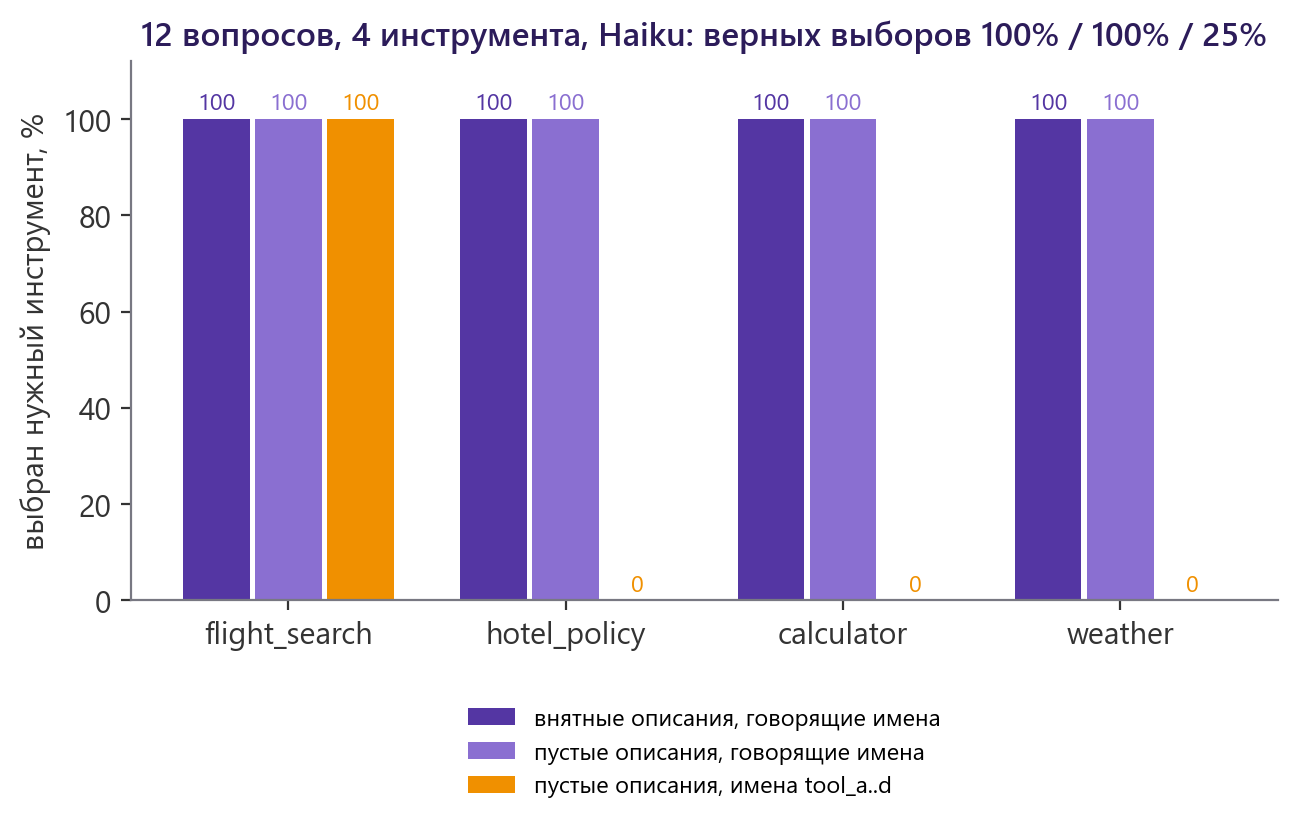

*Из третьей лекции: с пустыми описаниями и именами вида tool_a модель угадывает нужный инструмент в четверти случаев*

In [100]:
WIKI = "https://en.wikipedia.org/w/api.php"
WIKI_HEADERS = {"User-Agent": "agents-course-seminar01/1.0 (https://postypashki.ru; educational project)"}

def wiki(params, attempts=3):
    for attempt in range(attempts):
        r = requests.get(WIKI, params={**params, "format": "json"}, headers=WIKI_HEADERS, timeout=15)
        if r.status_code == 200 and r.headers.get("content-type", "").startswith("application/json"):
            return r.json()["query"]
        time.sleep(1.0 + attempt)
    raise RuntimeError(f"Википедия ответила {r.status_code}")

class SearchArgs(BaseModel):
    query: str = Field(description="короткий поисковый запрос: имя, название, термин")

class ExecArgs(BaseModel):
    code: str = Field(description="код на Python; результат надо напечатать через print")

In [7]:
def web_search(query: str) -> str:
    hits = wiki({"action": "query", "list": "search", "srsearch": query, "srlimit": 1})["search"]

    if not hits:
        return "No data"
    pages = wiki({"action":"query", "prop": "extracts", "explaintext": 1, "exintro": 1, "titles": hits[0]["title"]})["pages"]
    text = " ".join(next(iter(pages.values())).get("extract", "").split())
    return f"[{hits[0]["title"]}] {text[:5000]}"

In [8]:
def python_exec(code: str) -> str:
    try:
        r = subprocess.run([sys.executable, "-I", "-c", code], capture_output=True, text=True, timeout=5)
    except subprocess.TimeoutExpired:
        return "Код превысил 5 сек"
    out = (r.stdout + r.stderr).strip()
    return out[:5000] if out else "Код исполнился но результат пустой"


In [110]:
 python_exec("import time; time.sleep(10)")

'Код превысил 5 сек'

In [111]:
register(web_search, SearchArgs, "Ищет статью в англоязычной Википедии и возвращает её вступление")
register(python_exec, ExecArgs, "Выполняет код на Python в отдельном процессе и возвращает то, что он напечатал")

assert calculator("2+2") == "4"
assert calculator("2**10") == "1024"
assert "ошибка" in calculator("__import__('os')")
assert web_search("Scott Derrickson").startswith("[Scott Derrickson]")
assert web_search("qwxzv 1234567 nonsense") == "No data"
assert python_exec("print(sum(range(10)))") == "45"
assert "ZeroDivisionError" in python_exec("1/0")
assert "Код превысил 5 сек" in python_exec("import time; time.sleep(10)")
"инструменты работают"

'инструменты работают'

In [115]:
for q in ["Ed Wood", "Ed Wood film", "Kiss and Tell 1945 film"]:
    print(q, "->", web_search(q)[:220], "\n")

Ed Wood -> [Ed Wood] <p class="mw-empty-elt"> </p> <p><b>Edward Davis Wood Jr.</b> (October 10, 1924 – December 10, 1978) was an American filmmaker, actor and novelist. In the 1950s, Wood directed several low-budget science fiction 

Ed Wood film -> [Ed Wood (film)] <p class="mw-empty-elt"> </p> <p><i><b>Ed Wood</b></i> is a 1994 American biographical comedy-drama film directed and produced by Tim Burton and starring Johnny Depp as the eponymous cult filmmaker. The  

Kiss and Tell 1945 film -> [Kiss and Tell (1945 film)] <p class="mw-empty-elt"> </p> <p><i><b>Kiss and Tell</b></i> is a 1945 American comedy film starring then 17-year-old Shirley Temple as Corliss Archer. In the film, two teenage girls cause the 



In [117]:
run = agent("Сколько дней осталось до нового года? Посчитай кодом по сегодняшней дате.", MODELS["cheap"], ["python_exec"])
show_trace(run)

user     | Сколько дней осталось до нового года? Посчитай кодом по сегодняшней дате. 
assistant|  python_exec{"code":"from datetime import datetime\n\n# Получаем сегодняшнюю дату\ntoday = datetime.now()\n\n# Дата следующего Нового года\nnew_year = datetime(today.year + 1, 1, 1)\n\n# вычисляем разницу\nremaining_days = (new_year - today).days\nprint(remaining_days)"}
tool     | 109 
assistant| FINAL: 109 
шагов: 2, цена: 0.011 ¢, время: 2.8 c


user     | кто выиграл женский US Open 2026 по теннису 
assistant|  web_search{"query":"женский US Open 2026 по теннису"}
tool     | No data 
assistant| Информация о женском US Open 2026 по теннису пока недоступна. FINAL: информация недоступна. 
шагов: 2, цена: 0.008 ¢, время: 1.7 c


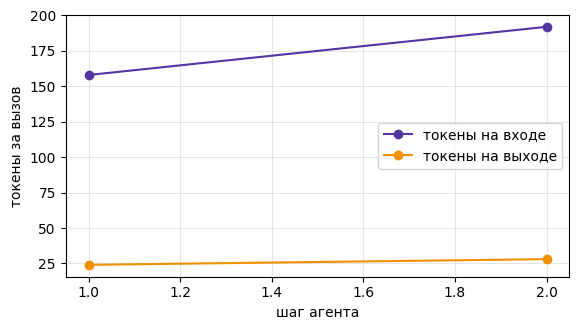

In [143]:
run = agent("кто выиграл женский US Open 2026 по теннису", MODELS["cheap"], ["web_search"])
show_trace(run)
context_chart(run);

In [144]:
class BlankArgs(BaseModel):
    text: str

def tool_a(text: str) -> str:
    return calculator(text)

def tool_b(text: str) -> str:
    return python_exec(text)

register(tool_a, BlankArgs, "Инструмент")
register(tool_b, BlankArgs, "Инструмент")
json.dumps(TOOLS["tool_b"]["schema"], ensure_ascii=False)

'{"type": "function", "function": {"name": "tool_b", "description": "Инструмент", "parameters": {"properties": {"text": {"title": "Text", "type": "string"}}, "required": ["text"], "title": "BlankArgs", "type": "object"}}}'

## Спринт 6. Прогон, трейсы, деньги

`run_tasks` прогоняет список задач в одной конфигурации, считает цену, время и число вызовов инструментов на задачу, проверяет ответ и пишет трейс в `traces/<конфигурация>/<модель>/<id>.json`. `report` сводит результаты в таблицу с главной колонкой курса `cost_per_correct`. `money_chart` рисует цену задачи против доли верных: левый верхний угол это «дёшево и хорошо», туда мы и хотим попасть. `steps_chart` показывает шаги, вызовы инструментов и секунды по конфигурациям.

На семинаре: пять задач GSM8K в четырёх конфигурациях (без инструментов, калькулятор, код, безымянные инструменты), три задачи HotpotQA в двух (без инструментов, поиск), всё на дешёвой модели, плюс сильная модель без инструментов на тех же восьми задачах.

Затем три повтора одного и того же прогона. Доля верных гуляет от повтора к повтору, и это первый разговор о размере выборки: домашка делается на 80 задачах именно поэтому. Ячейка с трейсом печатает один прогон по шагам: читать трейсы вслух это главный навык отладки агентов.

In [145]:
def final_answer(text):
    m = re.search(r"FINAL:\s*(.+)", text or "")
    return m.group(1).strip() if m else (text or "").strip()

def run_tasks(tasks, model, tool_names, config):
    folder = TRACES / config / model.split("/")[-1]
    folder.mkdir(parents=True, exist_ok=True)
    rows = []
    for task in tasks:
        try:
            run = agent(task["question"], model, tool_names)
        except Exception as e:
            run = Run(task["question"], f"ошибка: {e}", 0, [])
        ok = is_correct(task, final_answer(run.answer))
        rows.append({"config": config, "model": model.split("/")[-1], "id": task["id"], "source": task["source"],
                     "correct": ok, "steps": run.steps, "tool_calls": sum(m["role"] == "tool" for m in run.messages),
                     "cost": run.cost, "seconds": round(run.seconds, 1), "answer": final_answer(run.answer)[:60], "gold": task["answer"]})
        (folder / f"{task['id']}.json").write_text(json.dumps({"task": task, "answer": run.answer, "correct": ok, "cost": run.cost,
                                                              "messages": run.messages}, ensure_ascii=False, indent=1), encoding="utf-8")
    return pd.DataFrame(rows)

def report(results):
    rows = [summary(config, model, len(df), int(df["correct"].sum()), df["cost"].sum(), df["steps"].mean(), df["seconds"].mean())
            for (config, model), df in results.groupby(["config", "model"])]
    return pd.DataFrame(rows).sort_values("cost_per_task").reset_index(drop=True)

def money_chart(table, path="img/money_quality.png"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for _, r in table.iterrows():
        color = COLORS["red"] if "каскад" in r["config"] else COLORS["amber"] if "sonnet" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    fontsize=8, xytext=(6, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("цена задачи, центы (логарифмическая шкала)")
    ax.set_ylabel("доля верных ответов, %")
    ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

def steps_chart(results):
    g = results.groupby("config").agg(steps=("steps", "mean"), tool_calls=("tool_calls", "mean"), seconds=("seconds", "mean"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    g[["steps", "tool_calls"]].plot.bar(ax=axes[0], color=[COLORS["violet"], COLORS["teal"]], rot=12)
    axes[0].set_ylabel("в среднем на задачу")
    g["seconds"].plot.bar(ax=axes[1], color=COLORS["amber"], rot=12)
    axes[1].set_ylabel("секунд на задачу")
    for ax in axes:
        ax.grid(alpha=0.3, axis="y")
        ax.set_xlabel("")
    fig.tight_layout()
    return fig

CONFIGS = {"без инструментов": [], "калькулятор": ["calculator"], "код": ["python_exec"], "поиск": ["web_search"],
           "безымянные": ["tool_a", "tool_b"]}

In [147]:
gsm = load_tasks("/kaggle/input/datasets/artmakar04/qa-data/gsm8k_50.jsonl")[:5]
hotpot = load_tasks("/kaggle/input/datasets/artmakar04/qa-data/hotpot_30.jsonl")[:3]
frames = [run_tasks(gsm, MODELS["cheap"], CONFIGS[c], c) for c in ["без инструментов", "калькулятор", "код", "безымянные"]]
frames += [run_tasks(hotpot, MODELS["cheap"], CONFIGS[c], c) for c in ["без инструментов", "поиск"]]
frames.append(run_tasks(gsm + hotpot, MODELS["strong"], [], "без инструментов"))
results = pd.concat(frames, ignore_index=True)
results[["config", "model", "id", "correct", "steps", "tool_calls", "cost", "seconds", "answer", "gold"]]

,config,model,id,correct,steps,tool_calls,cost,seconds,answer,gold
0,без инструментов,gpt-4o-mini,gsm8k-0,True,1,0,0.000084,1.4,18,18
1,без инструментов,gpt-4o-mini,gsm8k-1,True,1,0,0.000072,1.2,3,3
2,без инструментов,gpt-4o-mini,gsm8k-2,True,1,0,0.000127,3.0,70000,70000
3,без инструментов,gpt-4o-mini,gsm8k-3,True,1,0,0.000081,2.2,540,540
4,без инструментов,gpt-4o-mini,gsm8k-4,True,1,0,0.000133,2.9,20,20
5,калькулятор,gpt-4o-mini,gsm8k-0,True,2,1,0.000085,1.3,18,18
6,калькулятор,gpt-4o-mini,gsm8k-1,True,2,1,0.000068,1.2,3,3
7,калькулятор,gpt-4o-mini,gsm8k-2,False,3,3,0.000173,2.5,65000,70000
8,калькулятор,gpt-4o-mini,gsm8k-3,True,3,2,0.000129,2.1,540,540
9,калькулятор,gpt-4o-mini,gsm8k-4,True,2,1,0.000097,1.3,20,20


In [148]:
table = report(results)
table

,config,model,n,accuracy,cost_per_task,cost_per_correct,avg_steps,avg_seconds
0,без инструментов,gpt-4o-mini,8,0.75,0.00008,0.00010,1.0,1.7
1,калькулятор,gpt-4o-mini,5,0.80,0.00011,0.00014,2.4,1.7
2,код,gpt-4o-mini,5,0.80,0.00067,0.00083,4.8,10.9
3,поиск,gpt-4o-mini,3,0.67,0.00070,0.00104,4.0,5.8
4,безымянные,gpt-4o-mini,5,1.00,0.00114,0.00114,7.0,14.1
5,без инструментов,claude-sonnet-4.6,8,1.00,0.00200,0.00200,1.0,2.9


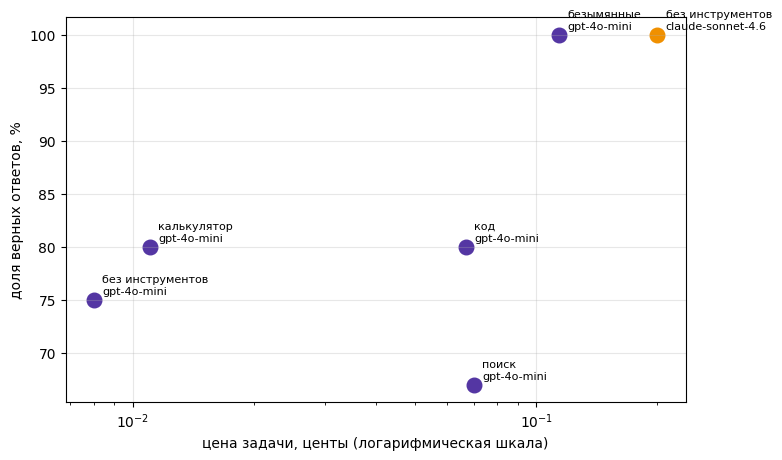

In [149]:
money_chart(table);

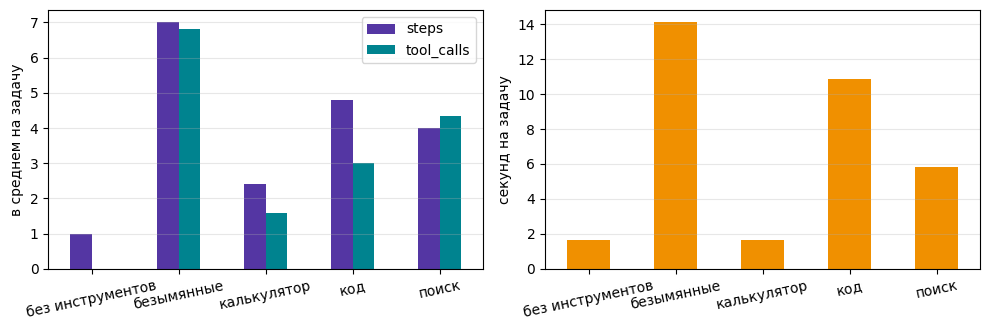

In [150]:
steps_chart(results[results["model"] == "gpt-4o-mini"]);

In [151]:
trace = json.loads(next((TRACES / "код" / "gpt-4o-mini").glob("gsm8k-*.json")).read_text(encoding="utf-8"))
show_trace(Run(trace["task"]["question"], trace["answer"], sum(m["role"] == "assistant" for m in trace["messages"]), trace["messages"], trace["cost"]))

user     | James decides to run 3 sprints 3 times a week. He runs 60 meters each sprint. How many total meters does he run a week? 
assistant|  python_exec{"code":"sprints_per_week = 3 * 3  # 3 sprints, 3 times a week\nmeters_per_sprint = 60\n# Total meters run in a week\ntotal_meters_per_week = sprints_per_week * meters_per_sprint\nprint(total_meters_per_week)"}
tool     | 540 
assistant| FINAL: 540 
шагов: 2, цена: 0.011 ¢, время: 0.0 c


In [152]:
repeats = pd.concat([run_tasks(gsm, MODELS["cheap"], ["python_exec"], f"код, повтор {i + 1}") for i in range(3)], ignore_index=True)
repeat_table = report(repeats)
repeat_table[["config", "accuracy", "cost_per_task", "avg_steps"]]

,config,accuracy,cost_per_task,avg_steps
0,"код, повтор 3",0.8,0.00027,3.0
1,"код, повтор 2",0.8,0.00046,4.0
2,"код, повтор 1",0.8,0.00094,6.4


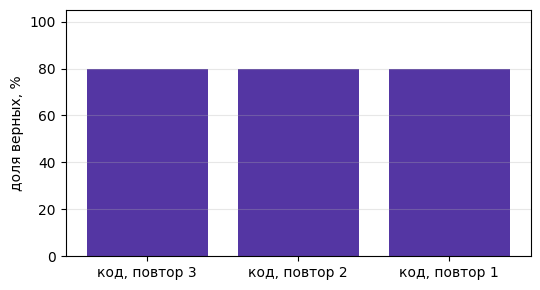

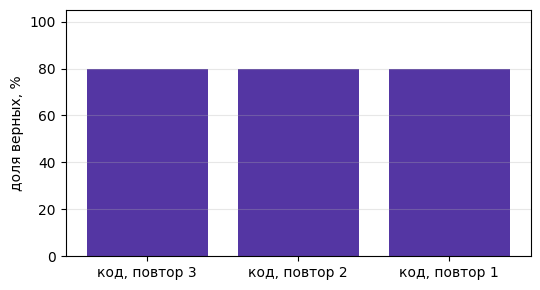

In [153]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(repeat_table["config"], repeat_table["accuracy"] * 100, color=COLORS["violet"])
ax.set_ylim(0, 105)
ax.set_ylabel("доля верных, %")
ax.grid(alpha=0.3, axis="y")
fig

In [154]:
ledger.table(), round(ledger.total, 3)

(                               calls  prompt  completion     cost  seconds
 tag         model                                                         
 agent       claude-haiku-4.5       4    7727         395  0.00970     6.46
             claude-sonnet-4.6     30   23829        3444  0.12315    88.12
             gpt-4o-mini          219  123467       15246  0.02585   317.90
 hello       gpt-4o-mini            1      18           5  0.00001     0.75
 struct      claude-haiku-4.5      14    4457        1673  0.01282    23.98
             claude-sonnet-4.6     10    2273         967  0.02132    23.17
             gpt-4o-mini           16    2883        1056  0.00107    26.28
 temperature gpt-4o-mini           10     270          76  0.00009     9.28
 window      claude-haiku-4.5       2      83         414  0.00215     5.19
             claude-sonnet-4.6      2      83         492  0.00763    11.89
             gpt-4o-mini            2      62         207  0.00013     4.11,
 0.204)

## Спринт 7. Каскад: дешёвая модель первой, сильная по необходимости

Идея FrugalGPT в самом простом виде. Дешёвая модель отвечает и заявляет уверенность от 0 до 1 (схема `Confident`). Если уверенность ниже порога, задача уходит сильной модели. `confident_answer` запоминает ответы каждой модели по задаче, поэтому развёртка по порогам не делает лишних вызовов: каждая модель спрашивается один раз на задачу, дальше арифметика.

Дырка одна: сам каскад. `cascade_sweep` считает точность, цену задачи и долю задач, ушедших наверх, для нескольких порогов: порог 0 это только дешёвая модель, порог 1.01 это сильная плюс потраченный впустую вызов дешёвой. `cascade_chart` рисует кривую цена против точности. `confidence_chart` показывает, чему верить: гистограмма заявленной уверенности отдельно для верных и неверных ответов. Последняя картинка спринта собирает все конфигурации семинара и точки каскада на одном поле.

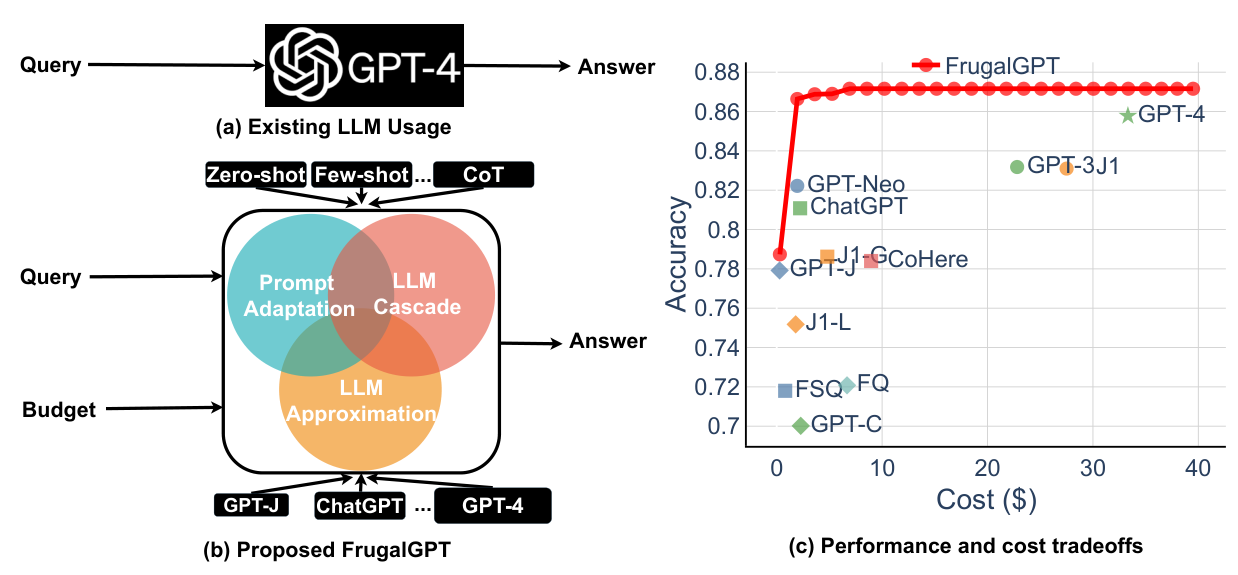

*Chen, Zaharia, Zou, 2023. FrugalGPT: каскад из дешёвых и сильных моделей достигает точности GPT-4 при цене в разы ниже. Красная линия это тезис курса одной картинкой*

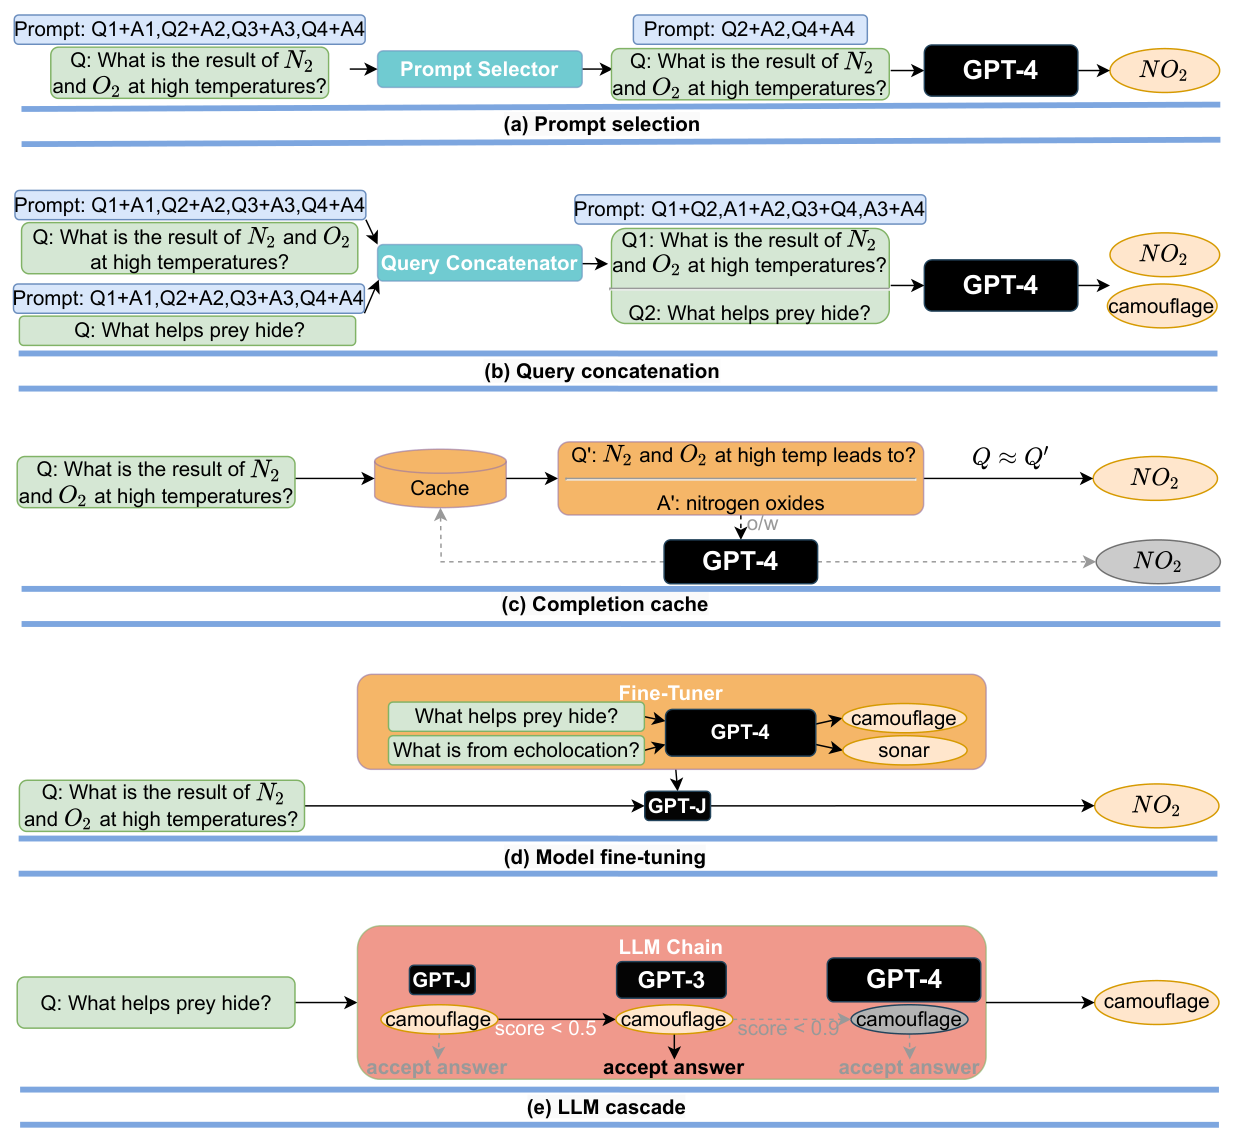

*Там же: пять приёмов в трёх семействах. Адаптация промпта (a, b), приближение сильной модели дешёвой через кэш и дообучение (c, d) и каскад (e). На семинаре собираем каскад*

In [156]:
class Confident(BaseModel):
    reasoning: str = Field(description="ход решения в два-три предложения")
    final: str = Field(description="только итоговый ответ")
    confidence: float = Field(description="честная уверенность в ответе от 0 до 1")

MEMO = {}

def confident_answer(task, model):
    key = (task["id"], model)
    if key not in MEMO:
        before = ledger.total
        try:
            ans = ask_structured(task["question"], model, Confident)
            MEMO[key] = {"final": ans.final, "confidence": ans.confidence, "correct": is_correct(task, ans.final)}
        except Exception:
            MEMO[key] = {"final": "", "confidence": 0.0, "correct": False}
        MEMO[key]["cost"] = ledger.total - before
    return dict(MEMO[key])

In [164]:
def cascade(task, threshold):
    cheap = confident_answer(task, MODELS['cheap'])
    if cheap["confidence"] >= threshold:
        return {**cheap, "escalated": False}
    strong = confident_answer(task, MODELS['strong'])
    return {**strong, "cost": cheap["cost"] + strong["cost"], "escalated": True}


In [165]:
def cascade_sweep(tasks, thresholds):
    rows = []
    for th in thresholds:
        outs = [cascade(t, th) for t in tasks]
        rows.append({"threshold": th, "accuracy": sum(o["correct"] for o in outs) / len(outs),
                     "cost_per_task": sum(o["cost"] for o in outs) / len(outs),
                     "escalated": sum(o["escalated"] for o in outs) / len(outs)})
    df = pd.DataFrame(rows)
    df["cost_per_correct"] = df["cost_per_task"] / df["accuracy"].replace(0, float("nan"))
    return df.round(5)

def cascade_chart(df):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(df["cost_per_task"] * 100, df["accuracy"] * 100, marker="o", color=COLORS["red"])
    for _, r in df.iterrows():
        ax.annotate(f"порог {r['threshold']}, наверх {r['escalated']:.0%}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    xytext=(6, -12), textcoords="offset points", fontsize=8)
    ax.set_xlabel("цена задачи, центы")
    ax.set_ylabel("доля верных, %")
    ax.grid(alpha=0.3)
    return fig

def confidence_chart(tasks, model):
    df = pd.DataFrame([confident_answer(t, model) for t in tasks])
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.hist(df[df["correct"]]["confidence"], bins=10, range=(0, 1), alpha=0.7, color=COLORS["teal"], label="верные")
    ax.hist(df[~df["correct"]]["confidence"], bins=10, range=(0, 1), alpha=0.7, color=COLORS["red"], label="неверные")
    ax.set_xlabel("заявленная уверенность")
    ax.set_ylabel("задач")
    ax.legend()
    ax.grid(alpha=0.3)
    return fig

In [166]:
cascade_tasks = load_tasks("/kaggle/input/datasets/artmakar04/qa-data/gsm8k_50.jsonl")[5:25]
cascade_df = cascade_sweep(cascade_tasks, [0.0, 0.7, 0.85, 0.95, 1.01])
cascade_df

,threshold,accuracy,cost_per_task,escalated,cost_per_correct
0,0.00,0.90,0.00009,0.0,0.00011
1,0.70,0.90,0.00009,0.0,0.00011
2,0.85,0.90,0.00009,0.0,0.00011
3,0.95,0.95,0.00174,0.5,0.00183
4,1.01,0.90,0.00286,1.0,0.00318


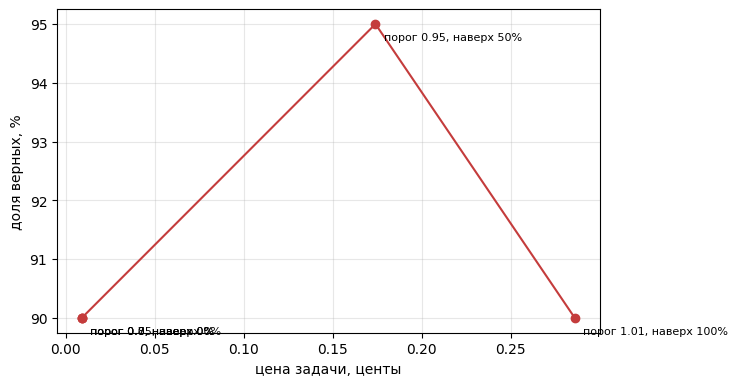

In [167]:
cascade_chart(cascade_df);

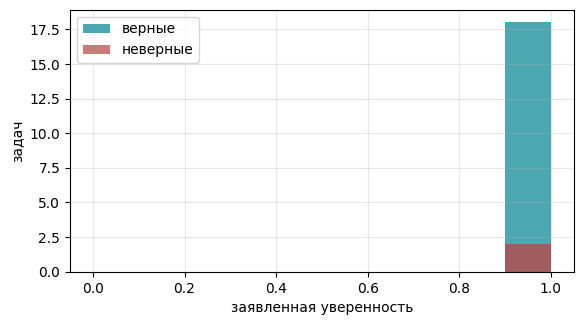

In [168]:
confidence_chart(cascade_tasks, MODELS["cheap"]);

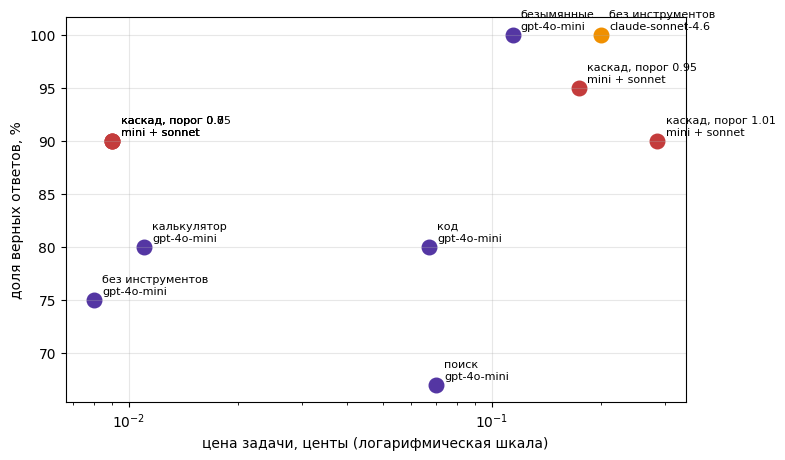

In [169]:
extra = pd.DataFrame([{"config": f"каскад, порог {r.threshold}", "model": "mini + sonnet", "n": len(cascade_tasks),
                       "accuracy": r.accuracy, "cost_per_task": r.cost_per_task, "cost_per_correct": r.cost_per_correct,
                       "avg_steps": 1, "avg_seconds": 0} for r in cascade_df.itertuples()])
money_chart(pd.concat([table, extra], ignore_index=True), "img/money_quality_all.png");

In [170]:
ledger.table(), round(ledger.total, 3)

(                               calls  prompt  completion     cost  seconds
 tag         model                                                         
 agent       claude-haiku-4.5       4    7727         395  0.00970     6.46
             claude-sonnet-4.6     30   23829        3444  0.12315    88.12
             gpt-4o-mini          219  123467       15246  0.02585   317.90
 hello       gpt-4o-mini            1      18           5  0.00001     0.75
 struct      claude-haiku-4.5      14    4457        1673  0.01282    23.98
             claude-sonnet-4.6     32    8429        3420  0.07659    81.69
             gpt-4o-mini           36    7340        3100  0.00296    69.78
 temperature gpt-4o-mini           10     270          76  0.00009     9.28
 window      claude-haiku-4.5       2      83         414  0.00215     5.19
             claude-sonnet-4.6      2      83         492  0.00763    11.89
             gpt-4o-mini            2      62         207  0.00013     4.11,
 0.261)

## Домашка

Срок: воскресенье 20.09, 23:59, ссылкой на репозиторий. Поставьте `HOMEWORK = True` и запустите: 50 задач GSM8K и 30 HotpotQA, дешёвая и средняя модели во всех конфигурациях, сильная без инструментов. Около часа и около доллара. Результаты лягут в `results.md`, `results_raw.csv` и `img/homework.png`. Что должно быть в репозитории и как оценивается, в `README.md`.

In [ ]:
HOMEWORK = True
if HOMEWORK:
    gsm, hotpot = load_tasks("gsm8k_50.jsonl"), load_tasks("hotpot_30.jsonl")
    frames = []
    for name in ["cheap", "mid"]:
        frames += [run_tasks(gsm, MODELS[name], CONFIGS[c], c) for c in ["без инструментов", "калькулятор", "код"]]
        frames += [run_tasks(hotpot, MODELS[name], CONFIGS[c], c) for c in ["без инструментов", "поиск"]]
    frames.append(run_tasks(gsm + hotpot, MODELS["strong"], [], "без инструментов"))
    homework = pd.concat(frames, ignore_index=True)
    homework.to_csv("results_raw.csv", index=False)
    homework_table = report(homework)
    Path("results.md").write_text(homework_table.to_string(index=False), encoding="utf-8")
    money_chart(homework_table, "img/homework.png")
    homework_table